# Project 2 — Supervised Learning: Fraud Detection Pipeline
**DecodeLabs Batch 2026**

**Goal:** Build and tune a classification model to identify fraudulent transactions in a highly imbalanced dataset (Kaggle Credit Card Fraud dataset — 284,807 transactions, 0.17% fraud).

**Requirements covered in this notebook:**
- SMOTE (via `imblearn`) to handle class imbalance
- Logistic Regression + Random Forest trained with `Scikit-Learn`
- **Zero data leakage**: train/test split happens *before* scaling/SMOTE, and SMOTE lives inside an `imblearn.pipeline.Pipeline` so it is only ever applied to the training fold (including inside `GridSearchCV`)
- Evaluation on strict **Precision, Recall, F1, and ROC-AUC** — accuracy is intentionally ignored


## 1. Setup — install & import libraries

In [1]:
!pip install -q imbalanced-learn

In [2]:
import numpy as np
import pandas as pd

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split, GridSearchCV, StratifiedKFold
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (
    classification_report,
    confusion_matrix,
    ConfusionMatrixDisplay,
    precision_recall_curve,
    roc_auc_score,
    roc_curve,
    average_precision_score,
)

from imblearn.over_sampling import SMOTE
from imblearn.pipeline import Pipeline as ImbPipeline

RANDOM_STATE = 42
sns.set_style("whitegrid")


## 2. Load the dataset




In [5]:
DATA_PATH = "creditcard.csv"  

df = pd.read_csv(DATA_PATH)
df


,Time,V1,V2,V3,V4,V5,V6,V7,V8,V9,...,V21,V22,V23,V24,V25,V26,V27,V28,Amount,Class
0,0.0,-1.359807,-0.072781,2.536347,1.378155,-0.338321,0.462388,0.239599,0.098698,0.363787,...,-0.018307,0.277838,-0.110474,0.066928,0.128539,-0.189115,0.133558,-0.021053,149.62,0
1,0.0,1.191857,0.266151,0.166480,0.448154,0.060018,-0.082361,-0.078803,0.085102,-0.255425,...,-0.225775,-0.638672,0.101288,-0.339846,0.167170,0.125895,-0.008983,0.014724,2.69,0
2,1.0,-1.358354,-1.340163,1.773209,0.379780,-0.503198,1.800499,0.791461,0.247676,-1.514654,...,0.247998,0.771679,0.909412,-0.689281,-0.327642,-0.139097,-0.055353,-0.059752,378.66,0
3,1.0,-0.966272,-0.185226,1.792993,-0.863291,-0.010309,1.247203,0.237609,0.377436,-1.387024,...,-0.108300,0.005274,-0.190321,-1.175575,0.647376,-0.221929,0.062723,0.061458,123.50,0
4,2.0,-1.158233,0.877737,1.548718,0.403034,-0.407193,0.095921,0.592941,-0.270533,0.817739,...,-0.009431,0.798278,-0.137458,0.141267,-0.206010,0.502292,0.219422,0.215153,69.99,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
284802,172786.0,-11.881118,10.071785,-9.834783,-2.066656,-5.364473,-2.606837,-4.918215,7.305334,1.914428,...,0.213454,0.111864,1.014480,-0.509348,1.436807,0.250034,0.943651,0.823731,0.77,0
284803,172787.0,-0.732789,-0.055080,2.035030,-0.738589,0.868229,1.058415,0.024330,0.294869,0.584800,...,0.214205,0.924384,0.012463,-1.016226,-0.606624,-0.395255,0.068472,-0.053527,24.79,0
284804,172788.0,1.919565,-0.301254,-3.249640,-0.557828,2.630515,3.031260,-0.296827,0.708417,0.432454,...,0.232045,0.578229,-0.037501,0.640134,0.265745,-0.087371,0.004455,-0.026561,67.88,0
284805,172788.0,-0.240440,0.530483,0.702510,0.689799,-0.377961,0.623708,-0.686180,0.679145,0.392087,...,0.265245,0.800049,-0.163298,0.123205,-0.569159,0.546668,0.108821,0.104533,10.00,0


## 3. Exploratory Data Analysis — confirm the imbalance

Class counts:
 Class
0    284315
1       492
Name: count, dtype: int64

Class percentages:
 Class
0    99.827
1     0.173
Name: proportion, dtype: float64


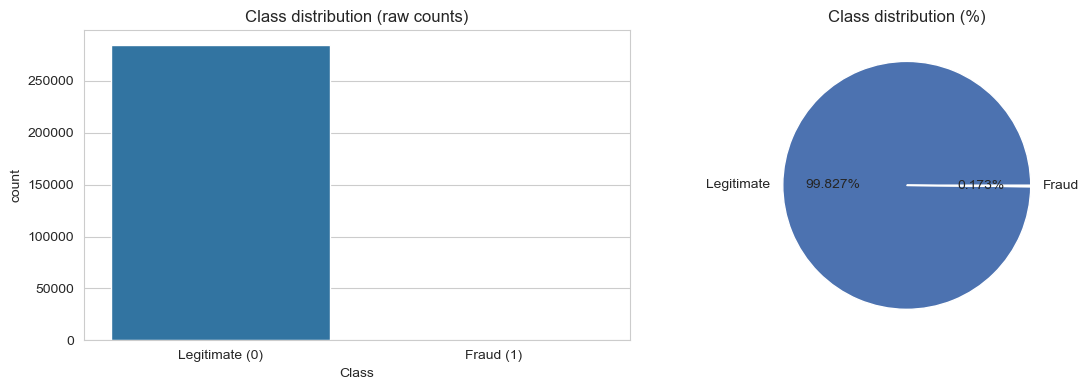

In [6]:
class_counts = df["Class"].value_counts()
class_pct = df["Class"].value_counts(normalize=True) * 100

print("Class counts:\n", class_counts)
print("\nClass percentages:\n", class_pct.round(3))

fig, ax = plt.subplots(1, 2, figsize=(12, 4))
sns.countplot(x="Class", data=df, ax=ax[0])
ax[0].set_title("Class distribution (raw counts)")
ax[0].set_xticks([0, 1])
ax[0].set_xticklabels(["Legitimate (0)", "Fraud (1)"])

ax[1].pie(class_counts, labels=["Legitimate", "Fraud"], autopct="%1.3f%%",
          colors=["#4C72B0", "#DD8452"])
ax[1].set_title("Class distribution (%)")
plt.tight_layout()
plt.show()


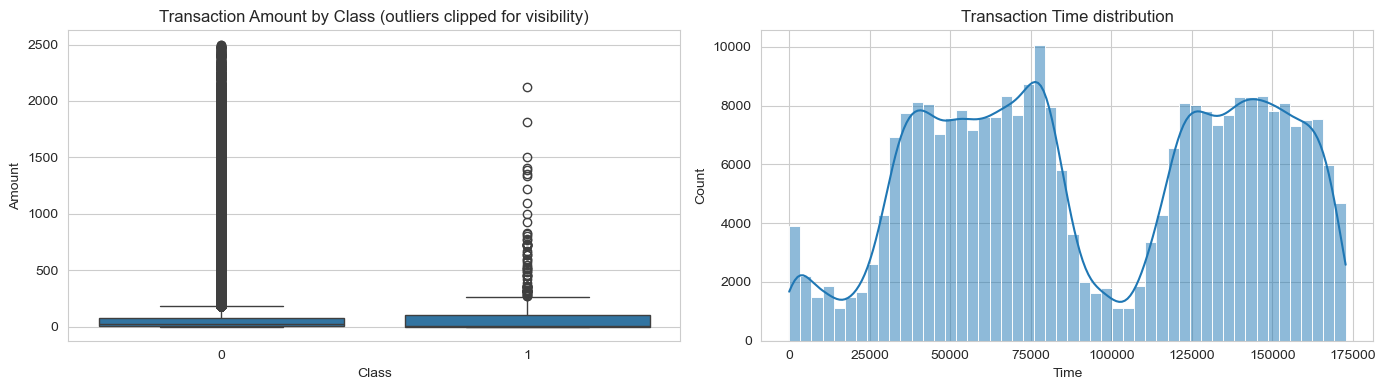

,count,mean,std,min,25%,50%,75%,max
Time,284807.0,9.481386e+04,47488.145955,0.000000,54201.500000,84692.000000,139320.500000,172792.000000
V1,284807.0,1.168375e-15,1.958696,-56.407510,-0.920373,0.018109,1.315642,2.454930
V2,284807.0,3.416908e-16,1.651309,-72.715728,-0.598550,0.065486,0.803724,22.057729
V3,284807.0,-1.379537e-15,1.516255,-48.325589,-0.890365,0.179846,1.027196,9.382558
V4,284807.0,2.074095e-15,1.415869,-5.683171,-0.848640,-0.019847,0.743341,16.875344
V5,284807.0,9.604066e-16,1.380247,-113.743307,-0.691597,-0.054336,0.611926,34.801666
V6,284807.0,1.487313e-15,1.332271,-26.160506,-0.768296,-0.274187,0.398565,73.301626
V7,284807.0,-5.556467e-16,1.237094,-43.557242,-0.554076,0.040103,0.570436,120.589494
V8,284807.0,1.213481e-16,1.194353,-73.216718,-0.208630,0.022358,0.327346,20.007208
V9,284807.0,-2.406331e-15,1.098632,-13.434066,-0.643098,-0.051429,0.597139,15.594995


In [7]:
# Quick look at Amount and Time distributions split by class
fig, ax = plt.subplots(1, 2, figsize=(14, 4))
sns.boxplot(x="Class", y="Amount", data=df[df["Amount"] < 2500], ax=ax[0])
ax[0].set_title("Transaction Amount by Class (outliers clipped for visibility)")

sns.histplot(df["Time"], bins=50, ax=ax[1], kde=True)
ax[1].set_title("Transaction Time distribution")
plt.tight_layout()
plt.show()

df.describe().T


In [8]:
# Check for missing values / duplicates
print("Missing values per column:\n", df.isnull().sum().sum())
print("Duplicate rows:", df.duplicated().sum())

# Drop exact duplicates (a common artifact in this dataset)
df = df.drop_duplicates()
print("Shape after dropping duplicates:", df.shape)


Missing values per column:
 0
Duplicate rows: 1081
Shape after dropping duplicates: (283726, 31)


## 4. Train/Test split — **before** any scaling or resampling

This is the single most important step to avoid data leakage. We split first, and every
downstream transformation (scaling, SMOTE) will only ever "see" the training fold.
`stratify=y` keeps the ~0.17% fraud rate consistent in both splits, matching the real world.


In [9]:
X = df.drop(columns=["Class"])
y = df["Class"]

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.20,
    stratify=y,
    random_state=RANDOM_STATE,
)

print("Train shape:", X_train.shape, " Fraud rate:", y_train.mean().round(5))
print("Test shape :", X_test.shape, " Fraud rate:", y_test.mean().round(5))


Train shape: (226980, 30)  Fraud rate: 0.00167
Test shape : (56746, 30)  Fraud rate: 0.00167


## 5. Build leak-proof pipelines with `imblearn.pipeline.Pipeline`

Two pipelines:
- **Logistic Regression** → needs `StandardScaler` (sensitive to feature scale) → then `SMOTE` → then the classifier
- **Random Forest** → tree splits are scale-invariant, so no scaler is needed → `SMOTE` → then the classifier

Using `imblearn`'s `Pipeline` (not `sklearn`'s) ensures `SMOTE` only resamples the **training fold**
during `fit()` — at `predict()`/`score()` time SMOTE is skipped automatically, and the same
guarantee holds *inside every fold of cross-validation and GridSearchCV*.


In [10]:
# Logistic Regression pipeline: Scale -> SMOTE -> Classify
lr_pipeline = ImbPipeline(steps=[
    ("scaler", StandardScaler()),
    ("smote", SMOTE(random_state=RANDOM_STATE)),
    ("classifier", LogisticRegression(max_iter=1000, random_state=RANDOM_STATE)),
])

# Random Forest pipeline: SMOTE -> Classify (no scaler needed)
rf_pipeline = ImbPipeline(steps=[
    ("smote", SMOTE(random_state=RANDOM_STATE)),
    ("classifier", RandomForestClassifier(random_state=RANDOM_STATE, n_jobs=1)),  
])


## 6. Hyperparameter tuning with `GridSearchCV`

`GridSearchCV` re-applies the pipeline (scaler + SMOTE + model) fresh inside every training
fold for every parameter combination, so tuning never touches the validation fold with
synthetic or scaled data — the validation fold always reflects the true, extreme imbalance.

We optimize for **ROC-AUC**, since it best captures separability between classes,
irrespective of decision threshold.


In [11]:
cv = StratifiedKFold(n_splits=3, shuffle=True, random_state=RANDOM_STATE)

# --- Logistic Regression grid ---
lr_param_grid = {
    "smote__k_neighbors": [5],
    "classifier__C": [0.1, 1.0, 10.0],
    "classifier__penalty": ["l2"],
}

lr_grid = GridSearchCV(
    lr_pipeline,
    param_grid=lr_param_grid,
    scoring="roc_auc",
    cv=cv,
    n_jobs=-1,      # LR is cheap, safe to parallelize
    verbose=1,
)

import time
start = time.time()
lr_grid.fit(X_train, y_train)
print(f"LR grid search took {time.time() - start:.1f} seconds")
print("Best LR params:", lr_grid.best_params_)
print("Best LR CV ROC-AUC:", round(lr_grid.best_score_, 4))


Fitting 3 folds for each of 3 candidates, totalling 9 fits
LR grid search took 527.5 seconds
Best LR params: {'classifier__C': 0.1, 'classifier__penalty': 'l2', 'smote__k_neighbors': 5}
Best LR CV ROC-AUC: 0.9804


In [12]:
cv = StratifiedKFold(n_splits=2, shuffle=True, random_state=RANDOM_STATE)

rf_param_grid = {
    "smote__k_neighbors": [5],
    "classifier__n_estimators": [80],
    "classifier__max_depth": [10, 15],   
}

rf_pipeline = ImbPipeline(steps=[
    ("smote", SMOTE(sampling_strategy=0.2, random_state=RANDOM_STATE)),  
    ("classifier", RandomForestClassifier(random_state=RANDOM_STATE, n_jobs=-1)),  
])

rf_grid = GridSearchCV(
    rf_pipeline,
    param_grid=rf_param_grid,
    scoring="roc_auc",
    cv=cv,
    n_jobs=1,      
    verbose=2,
)

import time
start = time.time()
rf_grid.fit(X_train, y_train)
print(f"RF grid search took {time.time() - start:.1f} seconds")
print("Best RF params:", rf_grid.best_params_)
print("Best RF CV ROC-AUC:", round(rf_grid.best_score_, 4))


Fitting 2 folds for each of 2 candidates, totalling 4 fits
[CV] END classifier__max_depth=10, classifier__n_estimators=80, smote__k_neighbors=5; total time= 6.6min
[CV] END classifier__max_depth=10, classifier__n_estimators=80, smote__k_neighbors=5; total time= 6.7min
[CV] END classifier__max_depth=15, classifier__n_estimators=80, smote__k_neighbors=5; total time= 8.2min
[CV] END classifier__max_depth=15, classifier__n_estimators=80, smote__k_neighbors=5; total time= 8.3min
RF grid search took 2617.6 seconds
Best RF params: {'classifier__max_depth': 10, 'classifier__n_estimators': 80, 'smote__k_neighbors': 5}
Best RF CV ROC-AUC: 0.9771


## 7. Final evaluation on the untouched test set

The test set was never scaled, resampled, or seen during tuning — this is the honest,
real-world read on how each model performs. We deliberately ignore accuracy and report
**Precision, Recall, F1, and ROC-AUC** instead.


===== Logistic Regression — Test Set Performance =====
              precision    recall  f1-score   support

  Legitimate     0.9998    0.9739    0.9866     56651
       Fraud     0.0531    0.8737    0.1001        95

    accuracy                         0.9737     56746
   macro avg     0.5264    0.9238    0.5434     56746
weighted avg     0.9982    0.9737    0.9852     56746

ROC-AUC: 0.9625
PR-AUC (Average Precision): 0.6687


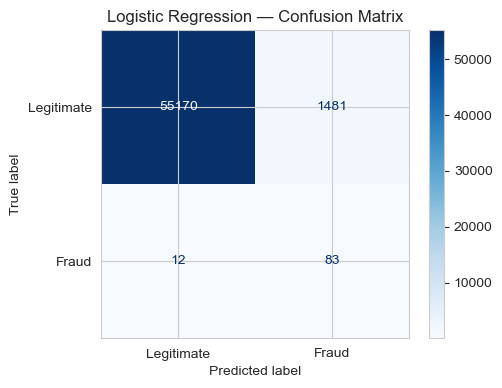

===== Random Forest — Test Set Performance =====
              precision    recall  f1-score   support

  Legitimate     0.9996    0.9998    0.9997     56651
       Fraud     0.8488    0.7684    0.8066        95

    accuracy                         0.9994     56746
   macro avg     0.9242    0.8841    0.9032     56746
weighted avg     0.9994    0.9994    0.9994     56746

ROC-AUC: 0.9698
PR-AUC (Average Precision): 0.7973


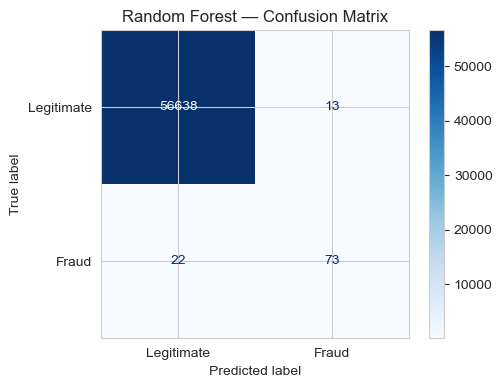

In [16]:
def evaluate_model(name, fitted_grid, X_test, y_test):
    best_model = fitted_grid.best_estimator_
    y_pred = best_model.predict(X_test)
    y_proba = best_model.predict_proba(X_test)[:, 1]

    print(f"===== {name} — Test Set Performance =====")
    print(classification_report(y_test, y_pred, target_names=["Legitimate", "Fraud"], digits=4))

    roc_auc = roc_auc_score(y_test, y_proba)
    pr_auc = average_precision_score(y_test, y_proba)
    print(f"ROC-AUC: {roc_auc:.4f}")
    print(f"PR-AUC (Average Precision): {pr_auc:.4f}")

    # Confusion matrix
    cm = confusion_matrix(y_test, y_pred)
    disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=["Legitimate", "Fraud"])
    fig, ax = plt.subplots(figsize=(5, 4))
    disp.plot(ax=ax, cmap="Blues", values_format="d")
    ax.set_title(f"{name} — Confusion Matrix")
    plt.show()

    return {"name": name, "y_pred": y_pred, "y_proba": y_proba, "roc_auc": roc_auc, "pr_auc": pr_auc}


lr_results = evaluate_model("Logistic Regression", lr_grid, X_test, y_test)
rf_results = evaluate_model("Random Forest", rf_grid, X_test, y_test)


## 8. ROC and Precision-Recall curves — side by side comparison

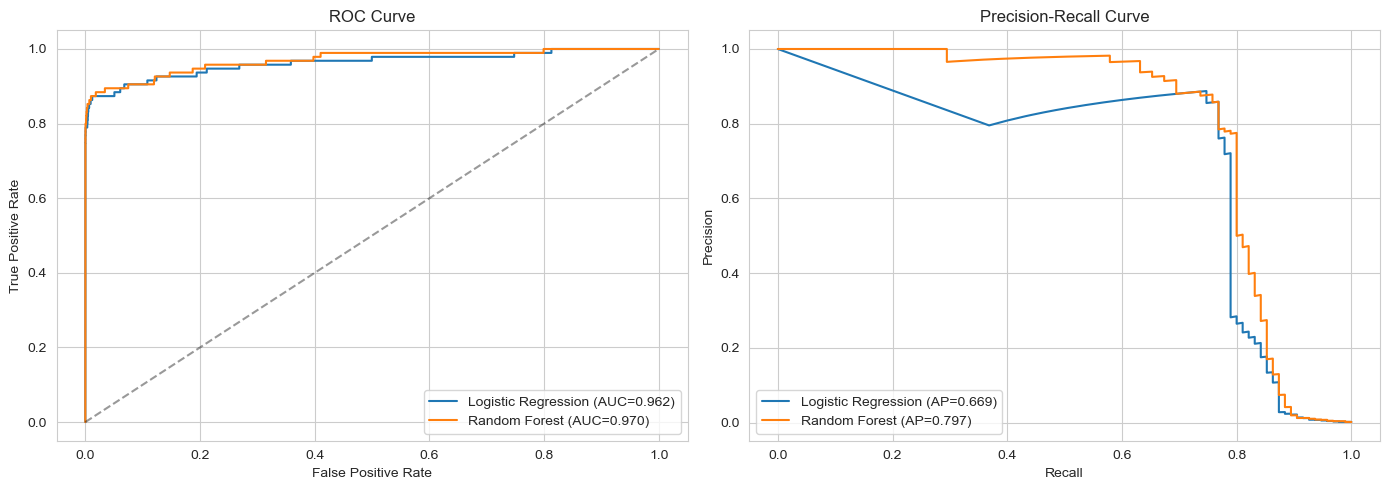

In [14]:
fig, ax = plt.subplots(1, 2, figsize=(14, 5))

for res in [lr_results, rf_results]:
    fpr, tpr, _ = roc_curve(y_test, res["y_proba"])
    ax[0].plot(fpr, tpr, label=f"{res['name']} (AUC={res['roc_auc']:.3f})")

    precision, recall, _ = precision_recall_curve(y_test, res["y_proba"])
    ax[1].plot(recall, precision, label=f"{res['name']} (AP={res['pr_auc']:.3f})")

ax[0].plot([0, 1], [0, 1], "k--", alpha=0.4)
ax[0].set_xlabel("False Positive Rate")
ax[0].set_ylabel("True Positive Rate")
ax[0].set_title("ROC Curve")
ax[0].legend()

ax[1].set_xlabel("Recall")
ax[1].set_ylabel("Precision")
ax[1].set_title("Precision-Recall Curve")
ax[1].legend()

plt.tight_layout()
plt.show()


## 9. Model comparison summary

A quick side-by-side table of the key metrics, plus which model to prefer for a
fraud-detection use case (where **missing fraud = direct financial loss**, so Recall
and ROC-AUC usually matter more than raw Precision).


In [17]:
summary = pd.DataFrame({
    "Model": [lr_results["name"], rf_results["name"]],
    "ROC-AUC": [lr_results["roc_auc"], rf_results["roc_auc"]],
    "PR-AUC (Avg Precision)": [lr_results["pr_auc"], rf_results["pr_auc"]],
})
summary = summary.sort_values("ROC-AUC", ascending=False).reset_index(drop=True)
summary


,Model,ROC-AUC,PR-AUC (Avg Precision)
0,Random Forest,0.969841,0.797297
1,Logistic Regression,0.962490,0.668666


## 10. (Optional) Feature importance — Random Forest

Since Random Forest is scale-invariant and typically the stronger model on this dataset,
it's worth inspecting which PCA-derived features (`V1`...`V28`) drive fraud predictions most.


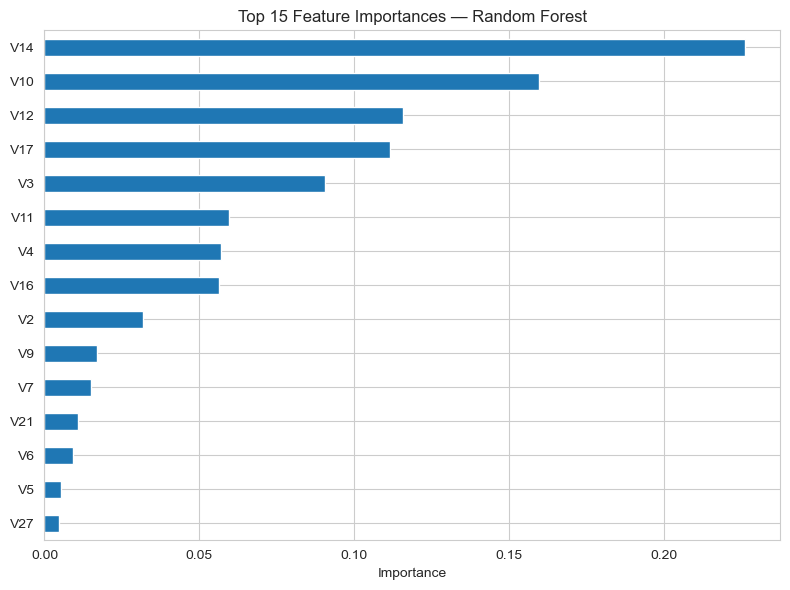

In [18]:
best_rf = rf_grid.best_estimator_.named_steps["classifier"]
importances = pd.Series(best_rf.feature_importances_, index=X_train.columns).sort_values(ascending=False)

plt.figure(figsize=(8, 6))
importances.head(15).plot(kind="barh")
plt.gca().invert_yaxis()
plt.title("Top 15 Feature Importances — Random Forest")
plt.xlabel("Importance")
plt.tight_layout()
plt.show()


---
### Key takeaways baked into this pipeline
- **No leakage**: split happens first; scaler + SMOTE live *inside* `imblearn.Pipeline`, so they're refit on every CV fold's training data only.
- **`imblearn.pipeline.Pipeline`, not `sklearn.pipeline.Pipeline`** — required because SMOTE needs to modify both `X` and `y`, which sklearn's pipeline API doesn't support.
- **Accuracy is never reported** — with a 99.8%/0.2% split it's meaningless. Precision, Recall, F1, and ROC-AUC/PR-AUC are the real scoreboard.
- **GridSearchCV tunes preprocessing and model hyperparameters together** (`smote__k_neighbors` alongside `classifier__C` / `classifier__max_depth`), which is the production-correct way to tune a full pipeline.
